In [1]:
from skimage.io import imread
import numpy as np
from scipy.io import loadmat
import scipy as sp
from matplotlib import pyplot as plt
import time
import lib

In [2]:
rootfolder = '.'

In [3]:
np.random.seed(12345)

Useful function for plot the dictionary

In [4]:
def get_dictionary_img(D):
    M, N = D.shape
    p = int(round(np.sqrt(M)))
    nnn = int(np.ceil(np.sqrt(N)))
    bound = 2
    img = np.ones((nnn*p+bound*(nnn-1), nnn*p+bound*(nnn-1)))
    for i in range(N):
        m = np.mod(i, nnn)
        n = int((i-m)/nnn)
        m = m * p + bound * m
        n = n * p + bound * n
        atom = D[:, i].reshape((p, p))
        if atom.min() < atom.max():
            atom = (atom - atom.min()) / (atom.max() - atom.min())
        img[m: m + p, n: n + p] = atom

    return img

Set all the paramters for the anomaly detection

In [5]:
# patch size (tha patch is square)
p = 15

# number of patches in the training set for dictionary learning
npatch_dictionary = 10000

# number of patches to estimate the confidence region
npatch_region = 1000

# paramters for the dictionary learning using the KSVD
niter_dl = 10
natom = int(np.round(p**2*1.5))
L = 4

# regularization parameters for the l1 sparse coding
lmbda = 0.18

Construct the training and validation sets
------------------------------------------

In [6]:
# load the training image and rescale it in [0,1]
img = imread(f'{rootfolder}/data/img_normal.png') / 255

# extract random patches from the image and store them in a matrices S, V
np.random.seed(12345)

m = np.random.randint(0, img.shape[0] - p, (npatch_dictionary, 2))
n = np.random.randint(0, img.shape[0] - p, (npatch_region, 2))

S = np.zeros((p**2, npatch_dictionary))
V = np.zeros((p**2, npatch_region))

for i in range(npatch_dictionary):
    S[:, i] = img[m[i, 0]: m[i, 0]+p, m[i, 1]:m[i, 1]+p].ravel()

for i in range(npatch_region):
    V[:, i] = img[n[i, 0]: n[i, 0]+p, n[i, 1]:n[i, 1]+p].ravel()

Dictionary Learning
-------------------
Perform preprocessing on the patches in $S$

In [7]:
# PREPROCESSING: exclude black patches from S
v = np.median(S, axis=0)
blackImages = S[:,v < 0.06]
S = S[:,v > 0.06]

print(f'Removed {blackImages.shape[1]} black patches over {S.shape[1] + blackImages.shape[1]} patches')

Removed 483 black patches over 10000 patches


In [8]:
# PREPROCESSING: remove the mean from each patch
S = S - np.mean(S, axis=0)

Perform dictionary learning via KSVD or MOD

In [9]:
# D = from lib import KSVD

# or load a precomputed dictionary
D = loadmat(f'{rootfolder}/data/dict_anom_det.mat')['D']

Show the learned dictionary

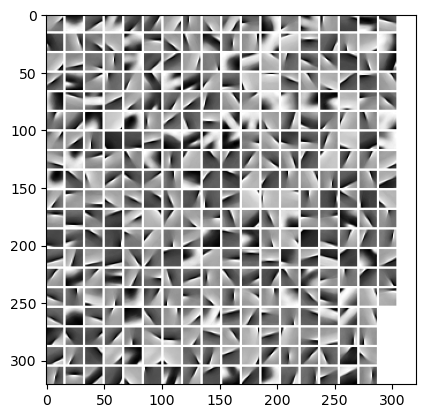

In [10]:
img_dict = get_dictionary_img(D)
plt.imshow(img_dict, cmap='gray')
plt.show()

## Confidence region estimation / density estimation

In [11]:
# PREPROCESSING: exclude black patches
v = np.median(V, axis=0)
blackImages = V[:,v < 0.06]
V = V[:,v > 0.06]

print(f'Removed {blackImages.shape[1]} black patches over {V.shape[1] + blackImages.shape[1]} patches')

Removed 54 black patches over 1000 patches


In [12]:
# PREPROCESSING: remove the mean from each patch
V = V - np.mean(V, axis=0)

In [13]:
# sparse coding of each patch in V
X = np.zeros((natom, npatch_region))
for i in range(V.shape[1]):
    # x = OMP(V[:, i], D, L, lmbda)
    f = lambda x: 0.5 * np.sum((D @ x - V[:, i]) ** 2)
    # the original function I am minimizing is f(x) + lmbda * np.sum(np.abs(x))
    F = lambda x: f(x) + lmbda * np.sum(np.abs(x))
    df = lambda x: D.T @ (D @ x) - D.T @ V[:, i]

    x = lib.ISTA(f, df, np.zeros(natom), 1e-3, 1e-3, 1e-3)

    X[:, i] = x

In [24]:
# computing the anomaly indicators (l1 norm, reconstruction error) for each
# patch in V

A = np.zeros((2, V.shape[1]))     # each column contains the values of the anomaly_scores for a patch

for i in range(V.shape[1]):
   A[:,i] = [np.linalg.norm(X[:,i], 1), np.linalg.norm(V[:,i] - D @ X[:,i])]

# Estimation of mean and covariance
mu = np.mean(A, axis=1)
Sigma = np.cov(A)

In [25]:
# estimation of the threshold that gives the desired false positive rate
# using the patches in V

FPR_target = 0.1

# compute the mahalanobis distance for each indicator vector in A
mahal_dist = np.zeros(V.shape[1])
for i in range(A.shape[1]):
   mahal_dist[i] = sp.spatial.distance.mahalanobis(A[:,i], mu, Sigma)

# set the threshold
threshold = np.percentile(mahal_dist, 100*(1-FPR_target))

## Test phase

In [26]:
# load the test image
img_test = imread(f'{rootfolder}/data/img_anom.png') / 255

imsz = img_test.shape

STEP = 1
# initialize the estimated image
heatmap = np.zeros_like(img)

# initialize the weight matrix
weights = np.zeros_like(img)

In [27]:
for i in range(0, imsz[0] - p + 1, STEP):
    for j in range(0, imsz[1] - p + 1, STEP):
        # extrach the patch with the top left corner at pixel (ii, jj)
        s = img_test[i:i+p, j:j+p].ravel()

        # if the median of s is to small set the anomaly score to 0:
        if np.median(s) <= 0.06:
            score = 0
        else:
            # subratct the mean to the patch
            s = s - np.mean(s)

            # perform the sparse coding
            f = lambda x: 0.5 * np.sum((D @ x - s) ** 2)
            # the original function I am minimizing is f(x) + lmbda * ||x||_1
            F = lambda x: f(x) + lmbda * np.sum(np.abs(x))
            df = lambda x: D.T @ (D @ x) - D.T @ s

            x = lib.ISTA(f, df, np.zeros(natom), 1e-3, 1e-3, 1e-3)

            # compute the anomaly indicators vector
            a = np.array([np.linalg.norm(x, 1), np.linalg.norm(s - D @ x)])

            # compute the anomaly score
            score = sp.spatial.distance.mahalanobis(a, mu, Sigma)

        # update the heatmap
        heatmap[i:i+p, j:j+p] = heatmap[i:i+p, j:j+p] + score * np.ones((p, p))

        # update the weight matrix
        weights[i:i+p, j:j+p] = weights[i:i+p, j:j+p] + np.ones((p, p))


In [28]:
# normalize the heatmap
heatmap = heatmap / weights

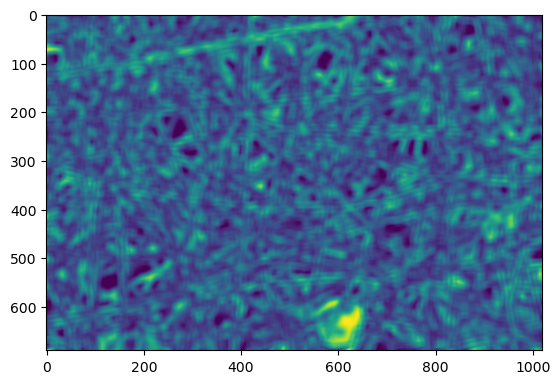

In [29]:
# plot the heatmap
plt.imshow(heatmap)

In [30]:
# build the detection mask, that has the same size of the test image
# each pixel in the mask has value 1 if the corresponding patch has been
# detected as anomalous, otherwise it has value 0
mask = np.zeros_like(img_test)

mask[heatmap > threshold] = 1

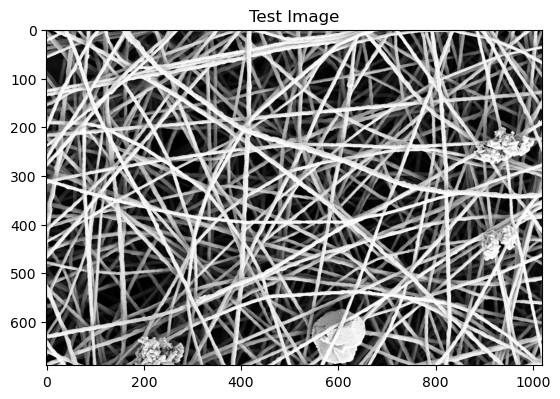

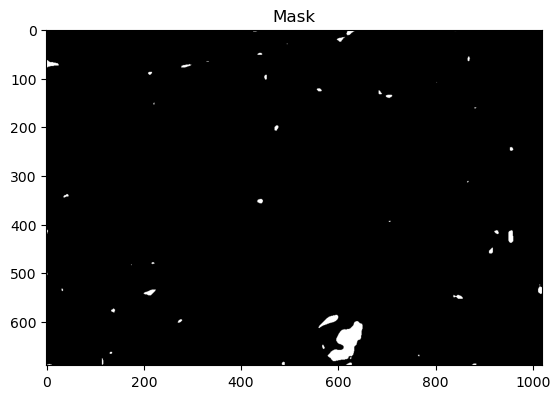

In [31]:
## show the results
plt.figure(3), plt.imshow(img_test, cmap='gray'), plt.title('Test Image')
plt.figure(4), plt.imshow(mask, cmap='gray'), plt.title('Mask')
plt.show()

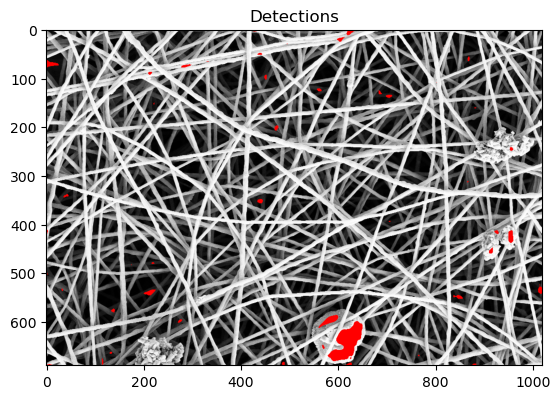

In [32]:
# combine the mask and the test image
img_color = np.zeros([img_test.shape[0], img_test.shape[1], 3])
img_temp = img_test.copy()
img_temp[mask > 0] = 1
img_color[:,:,0] = img_temp
img_temp = img_test.copy()
img_temp[mask > 0] = 0
img_color[:,:,1] = img_temp
img_temp = img_test.copy()
img_temp[mask > 0] = 0
img_color[:,:,2] = img_temp

plt.figure(5), plt.imshow(img_color), plt.title('Detections')
plt.show()